In [2]:
import torch

print("=" * 50)
print("🧩 张量创建方式")
print("=" * 50)

# 从列表创建
t1 = torch.tensor([[1, 2], [3, 4]])
print(f"从列表:      {t1.shape}, dtype={t1.dtype}")

# 全 0 / 全 1 / 单位矩阵
t2 = torch.zeros(2, 3)
t3 = torch.ones(2, 3)
t4 = torch.eye(3)
print(f"全零:         {t2}")
print(f"全一:         {t3}")
print(f"单位矩阵:\n{t4}")

# 随机张量
t5 = torch.rand(2, 3)       # 均匀分布 [0,1)
t6 = torch.randn(2, 3)      # 标准正态分布
print(f"均匀随机:     {t5}")
print(f"正态随机:     {t6}")

# 指定 dtype 和设备
t7 = torch.tensor([1.5, 2.5], dtype=torch.float32)
print(f"指定 float32: {t7.dtype}")

print()

print("=" * 50)
print("🔧 张量变形 & 索引")
print("=" * 50)

t = torch.arange(12).reshape(3, 4)
print(f"arange(12).reshape(3,4):\n{t}")

print(f"t[1,2] = {t[1,2].item()}")           # 取值 → Python 标量
print(f"t[:, 1:3]:\n{t[:, 1:3]}")            # 切片

t_flat = t.view(-1)                           # 展平
print(f"view(-1) 展平: {t_flat}")

t_t = t.t()                                    # 转置
print(f"转置 shape: {t_t.shape}")

print()

print("=" * 50)
print("🧮 数学运算")
print("=" * 50)

a = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32)
b = torch.tensor([[5, 6], [7, 8]], dtype=torch.float32)

print(f"a + b:\n{a + b}")
print(f"a - b:\n{a - b}")
print(f"a * b (逐元素乘):\n{a * b}")
print(f"a @ b (矩阵乘):\n{a @ b}")
print(f"a.mean() = {a.mean().item():.2f}")
print(f"a.sum()  = {a.sum().item()}")
print(f"a.pow(2):\n{a.pow(2)}")
print(f"a.sqrt():\n{a.sqrt()}")
print(f"a.exp():\n{a.exp()}")
print()

print("=" * 50)
print("⚡ 自动求导 (backward)")
print("=" * 50)

# 单变量
x = torch.tensor(2.0, requires_grad=True)
y = x ** 3 + 2 * x            # y = x³ + 2x
y.backward()
print(f"y = x³ + 2x, x=2.0")
print(f"dy/dx = {x.grad.item()}")   # 3x² + 2 = 14
print()

# 多变量（矩阵）
x2 = torch.tensor([[1., 2.], [3., 4.]], requires_grad=True)
z = x2.pow(2).sum()           # z = sum(x²)
z.backward()
print(f"z = sum(x²), x = [[1,2],[3,4]]")
print(f"dz/dx = \n{x2.grad}")        # 2x
print()

print("=" * 50)
print("🎮 GPU 加速")
print("=" * 50)

if torch.cuda.is_available():
    device = torch.device("cuda")
    t_cpu = torch.rand(1000, 1000)
    t_gpu = t_cpu.to(device)
    
    print(f"CPU tensor:  {t_cpu.device}")
    print(f"GPU tensor:  {t_gpu.device}")
    
    # 速度对比
    import time
    
    start = time.time()
    _ = t_cpu @ t_cpu
    cpu_time = time.time() - start
    
    start = time.time()
    _ = t_gpu @ t_gpu
    torch.cuda.synchronize()
    gpu_time = time.time() - start
    
    print(f"\n矩阵乘法 1000×1000 对比:")
    print(f"  CPU: {cpu_time:.4f}s")
    print(f"  GPU: {gpu_time:.4f}s")
    print(f"  加速比: {cpu_time/gpu_time:.1f}x")
else:
    print("本机无 GPU，用 CPU 替代演示")
print()

print("=" * 50)
print("📦 与 NumPy 互转")
print("=" * 50)

import numpy as np
arr_np = np.array([[1, 2], [3, 4]], dtype=np.float32)
t_from_np = torch.from_numpy(arr_np)
arr_from_t = t_from_np.numpy()
print(f"NumPy → Torch: {t_from_np.dtype} on {t_from_np.device}")
print(f"Torch → NumPy: {arr_from_t.dtype}")
print(f"共享内存: {np.shares_memory(arr_np, arr_from_t)}")  # True！改一个另一个也会变

🧩 张量创建方式
从列表:      torch.Size([2, 2]), dtype=torch.int64
全零:         tensor([[0., 0., 0.],
        [0., 0., 0.]])
全一:         tensor([[1., 1., 1.],
        [1., 1., 1.]])
单位矩阵:
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])
均匀随机:     tensor([[0.2813, 0.9679, 0.4459],
        [0.7066, 0.5859, 0.2224]])
正态随机:     tensor([[ 0.2922, -0.2829,  0.0497],
        [-0.0206,  0.0245,  0.7705]])
指定 float32: torch.float32

🔧 张量变形 & 索引
arange(12).reshape(3,4):
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
t[1,2] = 6
t[:, 1:3]:
tensor([[ 1,  2],
        [ 5,  6],
        [ 9, 10]])
view(-1) 展平: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])
转置 shape: torch.Size([4, 3])

🧮 数学运算
a + b:
tensor([[ 6.,  8.],
        [10., 12.]])
a - b:
tensor([[-4., -4.],
        [-4., -4.]])
a * b (逐元素乘):
tensor([[ 5., 12.],
        [21., 32.]])
a @ b (矩阵乘):
tensor([[19., 22.],
        [43., 50.]])
a.mean() = 2.50
a.sum()  = 10.0
a.pow(2):
tensor([[ 1.,  4.]

In [9]:
x1 = torch.tensor(10, requires_grad=True, dtype=torch.float32)
x2 = torch.tensor(20, requires_grad=True, dtype=torch.float32)

y = x1 ** 2 + x2 ** 2 + x1*x2

y.backward()

print(x1.grad)
print(x2.grad)

tensor(40.)
tensor(50.)


In [13]:
x = torch.tensor([10,20],requires_grad=True,dtype=torch.float32)
for _ in range(3):
    y = x**2 + 20
    y2 = y.mean()
    if x.grad is not None:
        x.grad.data.zero_()
    y2.backward()
    print(x.grad)

tensor([10., 20.])
tensor([10., 20.])
tensor([10., 20.])


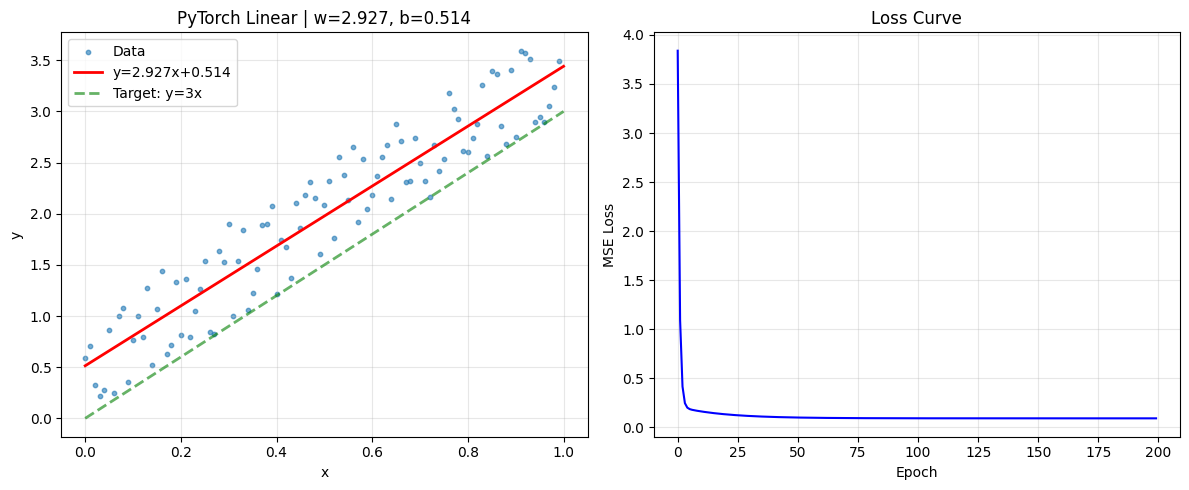

Fitted:  w = 2.9273,  b = 0.5139
Target:  w = 3.0,     b = 0.0

📊 手动实现 vs PyTorch 对比
步骤              手动实现                           PyTorch                       
--------------------------------------------------
前向              h = x*w + b                    model(x)                      
损失              loss = (h-y)²                  MSELoss()                     
梯度清零            (不需要)                          optimizer.zero_grad()         
反向传播            dw=2*(h-y)*x                   loss.backward()               
                db=2*(h-y)*1                                                 
参数更新            w -= lr*dw                     optimizer.step()              


In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ===== 用 PyTorch 实现梯度下降拟合 y = 3x =====

# 准备数据
_x = torch.tensor([i/100 for i in range(100)], dtype=torch.float32).reshape(-1, 1)
_y = torch.tensor([3*i + np.random.random() for i in _x], dtype=torch.float32).reshape(-1, 1)

# 定义一个线性模型: y = wx + b
model = nn.Linear(1, 1)

# 损失函数和优化器
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

# 训练
loss_history = []
for epoch in range(200):
    pred = model(_x)                # 前向
    loss = loss_fn(pred, _y)        # 算损失
    optimizer.zero_grad()           # 梯度清零
    loss.backward()                 # 自动求导
    optimizer.step()                # 自动更新 w, b
    loss_history.append(loss.item())

# 提取训练好的参数
w = model.weight.item()
b = model.bias.item()

# 画图
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(_x.numpy(), _y.numpy(), s=10, alpha=0.6, label='Data')
x_line = np.array([0, 1])
y_line = x_line * w + b
plt.plot(x_line, y_line, 'r-', linewidth=2, label=f'y={w:.3f}x+{b:.3f}')
plt.plot(x_line, 3 * x_line, 'g--', linewidth=2, alpha=0.6, label='Target: y=3x')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'PyTorch Linear | w={w:.3f}, b={b:.3f}')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(loss_history, 'b-')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Loss Curve')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Fitted:  w = {w:.4f},  b = {b:.4f}")
print(f"Target:  w = 3.0,     b = 0.0")

# ===== 和手动实现的对比 =====
print("\n" + "=" * 50)
print("📊 手动实现 vs PyTorch 对比")
print("=" * 50)
print(f"{'步骤':<15} {'手动实现':<30} {'PyTorch':<30}")
print(f"{'-'*50}")
print(f"{'前向':<15} {'h = x*w + b':<30} {'model(x)':<30}")
print(f"{'损失':<15} {'loss = (h-y)²':<30} {'MSELoss()':<30}")
print(f"{'梯度清零':<15} {'(不需要)':<30} {'optimizer.zero_grad()':<30}")
print(f"{'反向传播':<15} {'dw=2*(h-y)*x':<30} {'loss.backward()':<30}")
print(f"{'         ':<15} {'db=2*(h-y)*1':<30} {'':<30}")
print(f"{'参数更新':<15} {'w -= lr*dw':<30} {'optimizer.step()':<30}")


numpy数组与PyTorch张量的相互转换

- 转换方法说明：numpy数组转张量可使用两种方法，分别是`torch.tensor()`和`torch.from_numpy()`，两种方法转换后得到的结果均为张量类型。
- 反向转换方法：张量转numpy数组需要调用张量对象自带的`.numpy()`方法，不需要调用torch的顶层函数。
- 实际应用场景：深度学习模型训练和推理过程一般在GPU上以张量形式运行，绘图、损失汇总等操作需要在CPU上以numpy数组形式进行，因此必须先将张量从GPU迁移到CPU，再转换为numpy数组，否则会报错。

PyTorch张量的多种创建方法

- empty创建未初始化张量：使用`torch.empty()`创建张量，第一个参数为张量的形状size，创建出的张量是未经过初始化的，里面存储的是极小的随机值，后续需要手动填充值才能使用。
- 按分布生成随机张量：使用`torch.rand()`可以生成满足0到1区间均匀分布的张量，参数同样为形状size，生成的数值会按照均匀分布的规则随机抽取。
- 全0全1张量创建：使用`torch.zeros()`和`torch.ones()`可以分别生成全0和全1的张量，默认数据类型为浮点型，如果需要整数类型，可以通过`dtype`参数指定`torch.int32`或`torch.int64`（对应long）。
- 查看张量形状：PyTorch中张量的`size()`方法作用等价于numpy中的`shape`属性，都可以用来查看张量的形状，不需要强行记忆两种用法，记住一种即可。

张量维度运算规则

- 维度与numpy轴的对应关系：PyTorch中张量的`dim`（维度）等价于numpy数组中的`axis`（轴），运算规则完全一致，只是叫法不同。
- 按维度求和示例：以形状为`(2,3)`的二维张量为例，按照`dim=0`求和会得到3个结果，按照`dim=1`求和会得到2个结果。
- 三维张量求和规则：以形状为`(1,2,4)`的三维张量为例，按照`dim=0`求和得到形状为`(2,4)`的结果；按照`dim=1`求和得到形状为`(1,4)`的结果；按照`dim=2`求和得到形状为`(1,2)`的结果。

张量的广播机制

- 触发前提条件：两个形状不同的张量进行加减乘除算术运算时，如果满足广播的前提条件，就可以自动触发广播机制完成运算，不需要两个张量形状完全相同。
- 广播逻辑说明：形状为`(1,2)`的张量和形状为`(3,1)`的张量相加，广播后会得到形状为`(3,2)`的结果，`(1,2)`会被复制3次变成`(3,2)`，`(3,1)`会被复制2次变成`(3,2)`，再逐元素相加。
- 规则一致性：PyTorch张量的广播机制和numpy数组的广播机制规则完全一致，没有区别。

连续序列张量生成方法

- **`torch.arange`使用规则**：`torch.arange()`的用法和numpy的`arange()`完全一致，参数包含起始值、结束值和步长，生成的序列不包含结束值本身。
- 形状调整方式：生成一维连续序列后，可以直接调用`.reshape()`方法修改为任意合法形状，比如生成9个元素的一维序列可以修改为形状`(3,3)`的二维张量。

获取张量元素个数的方法

- 两种获取方式：获取张量的总元素个数有两种方法，分别是`torch.numel(张量对象)`和`张量对象.numel()`，两种方法都可以得到正确结果，均可使用。
- 适用范围说明：不管是一维、二维、三维还是n维张量，该方法都可以正确统计出全部元素的个数，不受维度数量限制。

修改张量数据类型的方法

- 常用转换方式：如果张量原本是整数类型，可以调用`.float()`方法转换为浮点类型；如果原本是浮点类型，可以调用`.int()`方法转换为整数类型。
- 查看当前类型：调用张量的`.dtype`属性就可以直接查看当前张量的数据类型，转换完成后可以直接查看确认转换结果。

张量维度交换操作

- **`transpose`使用方法**：使用`torch.transpose(张量, dim0, dim1)`可以交换张量的两个维度，对于形状`(2,5)`的二维张量，交换0轴和1轴后会得到形状`(5,2)`的张量。
- 规则一致性：该操作的规则和numpy数组的维度交换操作逻辑完全一致，用法基本相同。

**`item()`函数提取张量数值**

- 功能说明：`item()`函数可以从只包含1个元素的张量中提取出具体的普通数值，转换后脱离张量类型，方便后续绘图、保存等操作使用。
- 使用限制：该函数仅能处理只包含1个元素的张量，如果张量包含多个元素调用该函数会直接报错。
- 实际应用场景：深度学习训练过程中，损失值计算完成后是单元素张量，如果需要绘制损失曲线，必须调用`.item()`提取出具体数值才能进行绘图。

# 概率论在神经网络训练中的应用总结

## 1. 损失函数 = 最大似然估计（MLE）

神经网络训练的本质是 **最大化模型输出与真实标签的似然**。

| 任务 | 损失函数 | 对应的概率分布 |
|------|---------|--------------|
| 回归（MSE） | $\frac{1}{n}\sum (y-\hat{y})^2$ | 高斯分布 $y \sim \mathcal{N}(\hat{y}, \sigma^2)$ |
| 二分类（BCE） | $-\sum y\log\hat{y} + (1-y)\log(1-\hat{y})$ | 伯努利分布 $y \sim \text{Bernoulli}(\hat{y})$ |
| 多分类（CrossEntropy） | $-\sum y_k \log \hat{y}_k$ | 类别分布 $y \sim \text{Categorical}(\hat{y})$ |

**核心思想**: 用梯度下降**最小化损失** ≈ 用极大似然估计**最大化数据出现的概率**。

## 2. 正则化 = 贝叶斯先验

| 正则化 | 对应的先验分布 | 效果 |
|-------|--------------|------|
| **L2 正则化**（权重衰减） | 高斯先验 $w \sim \mathcal{N}(0, \lambda^{-1})$ | 权重趋向于**小且分散** |
| **L1 正则化** | 拉普拉斯先验 $w \sim \text{Laplace}(0, \lambda^{-1})$ | 权重趋向于**稀疏（很多为 0）** |

**核心思想**: 加正则化项 ≈ 告诉模型"参数不要太大，不要过于自信"。

## 3. Dropout = 伯努利采样

```python
# 训练时每个神经元以概率 p 保留
mask = torch.bernoulli(torch.full(size, p))  # 伯努利采样
output = input * mask / p
```

**本质**: 每次训练随机采样一个子网络，最终模型 ≈ 所有子网络的集成平均。

## 4. Batch Normalization = 标准化 + 可学习参数

对每个 batch 的数据做标准化 $(x - \mu) / \sigma$，其中 $\mu, \sigma$ 是当前 batch 的**样本均值与方差**。

**本质**: 用概率论中的**标准化变换**稳定数据分布，解决内部协变量偏移。

## 5. 初始化策略 = 控制随机变量的方差

权重初始化要保证**前向/反向传播中方差不爆炸不消失**：

```python
# Xavier 初始化（Sigmoid/tanh）
fan_in, fan_out = 100, 100
std = np.sqrt(2 / (fan_in + fan_out))  # 方差 = 2/(n_in+n_out)

# Kaiming 初始化（ReLU）
std = np.sqrt(2 / fan_in)
```

**本质**: 让信号在网络中传播时，**方差保持稳定**。

## 6. 评估指标 = 概率统计量

| 指标 | 公式 | 概率含义 |
|:---|:---|:-------|
| **准确率** | $\frac{TP + TN}{N}$ | 边缘概率 $P(\hat{y}=y)$ |
| **精确率** | $\frac{TP}{TP + FP}$ | 条件概率 $P(y=1 \mid \hat{y}=1)$ |
| **召回率** | $\frac{TP}{TP + FN}$ | 条件概率 $P(\hat{y}=1 \mid y=1)$ |
| **F1 分数** | $2 \cdot \frac{P \cdot R}{P + R}$ | 精确率和召回率的调和平均 |

## 7. 贝叶斯神经网络（进阶）

把每个权重从**固定值**换成**概率分布** $w \sim \mathcal{N}(\mu, \sigma^2)$，训练的是 $\mu$ 和 $\sigma$。

**好处**: 能得到预测的**置信区间**，而不是只给一个点估计。

---

## 一句话总结

> **神经网络训练 = 概率论在工程上的落地**
>
> - 损失函数 = 概率分布的负对数似然
> - 正则化 = 先验知识
> - Dropout = 随机采样近似集成
> - BN = 标准化变换
> - 初始化 = 控制方差传播
>
> 考研概率论里学的那些分布（高斯、伯努利、拉普拉斯）和统计量（均值、方差），在这里**全部用上了**。


In [ ]:
# ===== 卷积运算：图像 × 卷积核 =====

image = [[1, 2, 3, 4],
         [5, 6, 7, 8],
         [9, 10, 11, 12],
         [13, 14, 15, 16]]

kernel = [[1,  0],
          [0, -1]]

# 结果矩阵大小: (4-2+1) × (4-2+1) = 3 × 3
result = [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]]

# ---------- 卷积计算 ----------
for i in range(3):           # i 遍历结果行
    for j in range(3):       # j 遍历结果列
        s = 0
        for m in range(2):   # m 遍历卷积核行
            for n in range(2):  # n 遍历卷积核列
                s += image[i+m][j+n] * kernel[m][n]
        result[i][j] = s

# 打印结果
for row in result:
    print(row)


[-5, -5, -5]
[-5, -5, -5]
[-5, -5, -5]


In [21]:
data = torch.tensor(
[
[[0.5078, 0.2781, 0.3335, 0.4427, 0.7964],
 [0.7584, 0.2672, 0.3906, 0.4314, 0.4188]],
[[0.7904, 0.2729, 0.2646, 0.4162, 0.4124],
 [0.5050, 0.1037, 0.2326, 0.4085, 0.4596]],
[[0.7126, 0.4523, 0.5729, 0.4901, 0.6933],
 [0.1695, 0.1700, 0.1220, 0.4271, 0.4141]],
[[0.7892, 0.2588, 0.3648, 0.5982, 0.4003],
 [0.1344, 0.1349, 0.2387, 0.4515, 0.4261]
]])

print(f"data.shape = {data.shape}")  # (4, 2, 5)

print("=" * 40)
print("2.1 大于0.7所在的行")
print("=" * 40)

mask = data > 0.7
has_large = mask.any(dim=2)         # 每个块每行是否有 > 0.7 → (4, 2)
row_idx = has_large.nonzero()       # 非零位置的坐标

print("大于0.7所在的 (块, 行):")
for idx in row_idx:
    print(f"  块 {idx[0].item()}, 行 {idx[1].item()}")
    print(f"    该行数据: {data[idx[0], idx[1]]}")

print()
print("=" * 40)
print("2.2 使用切片取出以下数据")
print("=" * 40)

# ---------- 填写切片表达式 ----------
result = data[:, 0, 1:]
result[0] = data[0, 1, 1:]
# ----------------------------------

print(f"结果:\n{result}")
print(f"结果 shape: {result.shape}")

data.shape = torch.Size([4, 2, 5])
2.1 大于0.7所在的行
大于0.7所在的 (块, 行):
  块 0, 行 0
    该行数据: tensor([0.5078, 0.2781, 0.3335, 0.4427, 0.7964])
  块 0, 行 1
    该行数据: tensor([0.7584, 0.2672, 0.3906, 0.4314, 0.4188])
  块 1, 行 0
    该行数据: tensor([0.7904, 0.2729, 0.2646, 0.4162, 0.4124])
  块 2, 行 0
    该行数据: tensor([0.7126, 0.4523, 0.5729, 0.4901, 0.6933])
  块 3, 行 0
    该行数据: tensor([0.7892, 0.2588, 0.3648, 0.5982, 0.4003])

2.2 使用切片取出以下数据
结果:
tensor([[0.2672, 0.3906, 0.4314, 0.4188],
        [0.2729, 0.2646, 0.4162, 0.4124],
        [0.4523, 0.5729, 0.4901, 0.6933],
        [0.2588, 0.3648, 0.5982, 0.4003]])
结果 shape: torch.Size([4, 4])


In [22]:
# ===== 计算 IoU（交并比）=====
# 候选框和真实框的格式: [x1, y1, x2, y2]

boxes = torch.tensor([[26, 39, 43, 41],
                      [27, 26, 41, 41],
                      [45, 57, 49, 69],
                      [25, 36, 59, 40]], dtype=torch.float32)

target_box = torch.tensor([46, 57, 49, 68], dtype=torch.float32)

def compute_iou(box, target):
    # ---- 计算交集 ----
    x1 = max(box[0], target[0])
    y1 = max(box[1], target[1])
    x2 = min(box[2], target[2])
    y2 = min(box[3], target[3])
    
    # TODO: 补全代码
    inter = max(0, x2-x1)*max(0,y2-y1)
    
    # ---- 计算并集 ----
    area_box = (box[2] - box[0]) * (box[3] - box[1])
    area_target = (target[2] - target[0]) * (target[3] - target[1])
    
    # TODO: 补全代码
    union = area_box + area_target - inter
    
    return inter / union

print(f"{'候选框':<30} {'IoU':<10}")
print("-" * 40)
for i, box in enumerate(boxes):
    iou = compute_iou(box, target_box)
    print(f"  boxes[{i}] {box.int().tolist()!s:<20} {iou:.4f}")

候选框                            IoU       
----------------------------------------
  boxes[0] [26, 39, 43, 41]     0.0000
  boxes[1] [27, 26, 41, 41]     0.0000
  boxes[2] [45, 57, 49, 69]     0.6875
  boxes[3] [25, 36, 59, 40]     0.0000
